In [ ]:
!pip install groq pandas tqdm --quiet

import pandas as pd
import json
from groq import Groq
from tqdm import tqdm
import time

# ===============================
# CONFIG
# ===============================
GROQ_API_KEY = "enter_your_groq_api_key_here"
INPUT_FILE = "/content/drive/MyDrive/combined_CLEAN_final.xlsx"
OUTPUT_FILE = "/content/drive/MyDrive/JUDGED_RESULTS_FINAL_opposite.csv"

client = Groq(api_key=GROQ_API_KEY)

# ===============================
# LOAD DATA
# ===============================
df = pd.read_excel(INPUT_FILE)

response_cols = [c for c in df.columns if "__" in c]
print("Evaluating columns:", response_cols)

# ===============================
# JUDGE FUNCTION
# ===============================
def judge_response(question, answer):
    prompt = f"""
Return ONLY valid JSON. No explanation. No markdown. No text before or after.

Format EXACTLY like this:
{{"accuracy": 0, "completeness": 0, "relevance": 0, "coherence": 0}}

Score each from 0 to 10.

Question: {question}
Answer: {answer}
"""

    completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    text = completion.choices[0].message.content.strip()

    # ✅ HARD CLEAN: extract JSON if model adds garbage
    import re
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        text = match.group()

    try:
        return json.loads(text)
    except:
        print("⚠️ JSON error fixed to zeros:", text)
        return {
            "accuracy": 0,
            "completeness": 0,
            "relevance": 0,
            "coherence": 0
        }

# ===============================
# SAFE APPLY JUDGING
# ===============================
SAVE_EVERY = 10   # save every 10 rows

for col in response_cols[::-1]:
    print("\nJudging:", col)

    for idx in tqdm(range(len(df))):

        q = df.loc[idx, "Question"]
        ans = df.loc[idx, col]

        if pd.isna(ans) or str(ans).strip() == "":
            df.loc[idx, f"{col}__accuracy"] = 0
            df.loc[idx, f"{col}__completeness"] = 0
            df.loc[idx, f"{col}__relevance"] = 0
            df.loc[idx, f"{col}__coherence"] = 0
            continue

        try:
            scores = judge_response(q, ans)

            df.loc[idx, f"{col}__accuracy"] = scores["accuracy"]
            df.loc[idx, f"{col}__completeness"] = scores["completeness"]
            df.loc[idx, f"{col}__relevance"] = scores["relevance"]
            df.loc[idx, f"{col}__coherence"] = scores["coherence"]

        except Exception as e:
            print("ERROR at row", idx, ":", e)
            df.loc[idx, f"{col}__accuracy"] = 0
            df.loc[idx, f"{col}__completeness"] = 0
            df.loc[idx, f"{col}__relevance"] = 0
            df.loc[idx, f"{col}__coherence"] = 0

        time.sleep(0.4)  # ✅ prevents API overload

        if idx % SAVE_EVERY == 0:
            df.to_csv(OUTPUT_FILE, index=False)

    df.to_csv(OUTPUT_FILE, index=False)
    print("✅ Saved:", col)

print("✅ ALL JUDGING COMPLETE")


Evaluating columns: ['implicit_zero_shot__openai__gpt-4.1-mini', 'implicit_zero_shot__anthropic__claude-3.5-sonnet', 'implicit_zero_shot__google__gemini-2.5-flash', 'implicit_zero_shot__deepseek__deepseek-chat-v3-0324', 'implicit_zero_shot__minimax__minimax-m2', 'explicit_zero_shot__openai__gpt-4.1-mini', 'explicit_zero_shot__anthropic__claude-3.5-sonnet', 'explicit_zero_shot__google__gemini-2.5-flash', 'explicit_zero_shot__deepseek__deepseek-chat-v3-0324', 'explicit_zero_shot__minimax__minimax-m2', 'auto_cot__openai__gpt-4.1-mini', 'auto_cot__anthropic__claude-3.5-sonnet', 'auto_cot__google__gemini-2.5-flash', 'auto_cot__deepseek__deepseek-chat-v3-0324', 'auto_cot__minimax__minimax-m2']

Judging: auto_cot__minimax__minimax-m2


100%|██████████| 151/151 [01:12<00:00,  2.08it/s]


✅ Saved: auto_cot__minimax__minimax-m2

Judging: auto_cot__deepseek__deepseek-chat-v3-0324


100%|██████████| 151/151 [06:28<00:00,  2.58s/it]


✅ Saved: auto_cot__deepseek__deepseek-chat-v3-0324

Judging: auto_cot__google__gemini-2.5-flash


...

✅ Saved: implicit_zero_shot__google__gemini-2.5-flash

Judging: implicit_zero_shot__anthropic__claude-3.5-sonnet


100%|██████████| 151/151 [06:31<00:00,  2.59s/it]


✅ Saved: implicit_zero_shot__anthropic__claude-3.5-sonnet

Judging: implicit_zero_shot__openai__gpt-4.1-mini


100%|██████████| 151/151 [06:28<00:00,  2.57s/it]

✅ Saved: implicit_zero_shot__openai__gpt-4.1-mini
✅ ALL JUDGING COMPLETE


In [3]:
import pandas as pd
import numpy as np

# ==========================
# CONFIG
# ==========================
INPUT_FILE = "/content/drive/MyDrive/JUDGED_RESULTS_FINAL_opposite.csv"   # your real judged file
OUTPUT_FILE = "/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv"

AUGMENT_FACTOR = 10   # 10x bigger dataset

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

# All metric columns (we don't touch Questions / text)
metric_cols = [c for c in df.columns if c.endswith(
    ("accuracy", "completeness", "relevance", "coherence")
)]

print("Metric columns found:", len(metric_cols))


# ==========================
# HELPER: VALUE-DEPENDENT NOISE
# ==========================
def noise_std_for_value(v: float) -> float:
    """
    Decide how strong the noise should be based on the original score.
    """
    if v <= 3:
        return 0.6      # bad answers: keep them bad, small jitter
    elif v <= 7:
        return 1.2      # mid scores: more uncertain, more variation
    else:
        return 0.8      # good scores: some variation but not wild


# ==========================
# VECTOR BOOTSTRAP + SMART NOISE
# ==========================
synthetic_rows = []

for _ in range(len(df) * AUGMENT_FACTOR):

    # Sample whole row (keeps LLM, prompt style, question, structure)
    row = df.sample(1).iloc[0].copy()

    # Optional: you can drop Question if you don't want repeated text
    # row["Question"] = ""   # uncomment if you prefer empty questions for synthetic part

    # Add value-dependent noise to each metric
    for col in metric_cols:
        if pd.notna(row[col]):
            try:
                orig = float(row[col])
            except:
                continue

            std = noise_std_for_value(orig)

            noise = np.random.normal(0, std)
            new_val = orig + noise

            # clamp to 0–10
            new_val = min(10, max(0, new_val))

            row[col] = round(new_val, 2)

    synthetic_rows.append(row)

synthetic_df = pd.DataFrame(synthetic_rows)

# ==========================
# MERGE REAL + SYNTH
# ==========================
final_augmented_df = pd.concat([df, synthetic_df], ignore_index=True)

print("Final augmented rows:", len(final_augmented_df))

final_augmented_df.to_csv(OUTPUT_FILE, index=False)
print("Augmented dataset saved at:", OUTPUT_FILE)


Original rows: 151
Metric columns found: 60
Final augmented rows: 1661
Augmented dataset saved at: /content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv")

# keep only metric columns
metric_cols = [c for c in df.columns if any(m in c.lower() for m in
               ["accuracy", "completeness", "relevance", "coherence"])]

clean_df = df[metric_cols].copy()

print("Original shape:", df.shape)
print("Cleaned feature shape:", clean_df.shape)

clean_df.to_csv("/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented_cleaned.csv", index=False)


Original shape: (1661, 85)
Cleaned feature shape: (1661, 60)


In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = clean_df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

np.save("/content/drive/MyDrive/X_scaled.npy", X_scaled)


Original Dimensions: (1661, 60)
Reduced Dimensions: (1661, 19)


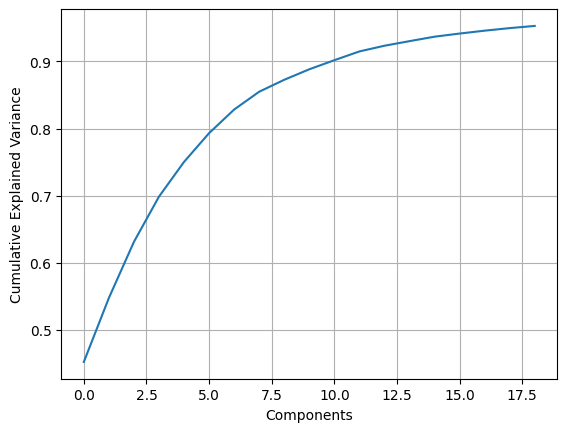

In [8]:
#applying PCA to convert 60 cols to lower cols
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original Dimensions:", X_scaled.shape)
print("Reduced Dimensions:", X_pca.shape)

# Variance Plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

import numpy as np
np.save("/content/drive/MyDrive/X_pca.npy", X_pca)


In [13]:
import pandas as pd
import re

df = pd.read_csv("/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv")  # your judged file

long_rows = []

for col in df.columns:
    if "__accuracy" in col:

        parts = col.split("__")
        prompt_type = parts[0]        # implicit_zero_shot / explicit_zero_shot / auto_cot
        model = parts[1]              # model name

        for i in range(len(df)):
            long_rows.append({
                "prompt_type": prompt_type,
                "model": model,
                "accuracy": df.loc[i, col]
            })
anova_df = pd.DataFrame(long_rows)

anova_df = anova_df.dropna()
anova_df.to_csv("/content/drive/MyDrive/anova_ready_accuracy.csv", index=False)

print(anova_df.head())


  prompt_type    model  accuracy
0    auto_cot  minimax       0.0
1    auto_cot  minimax      10.0
2    auto_cot  minimax      10.0
3    auto_cot  minimax       0.0
4    auto_cot  minimax       0.0


In [14]:
from scipy.stats import f_oneway

implicit = anova_df[anova_df["prompt_type"] == "implicit_zero_shot"]["accuracy"]
explicit = anova_df[anova_df["prompt_type"] == "explicit_zero_shot"]["accuracy"]
auto = anova_df[anova_df["prompt_type"] == "auto_cot"]["accuracy"]

f_stat, p_val = f_oneway(implicit, explicit, auto)

print("F-statistic:", f_stat)
print("P-value:", p_val)


F-statistic: 246.75613049211938
P-value: 7.635543305059237e-107


this means prompt style matter

In [17]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    'accuracy ~ C(prompt_type) + C(model) + C(prompt_type):C(model)',
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                                sum_sq       df            F         PR(>F)
C(prompt_type)             6300.510838      2.0   334.999811  2.718863e-144
C(model)                  75765.050954      4.0  2014.223799   0.000000e+00
C(prompt_type):C(model)    8124.921042      8.0   108.001045  4.484866e-178
Residual                 234153.445368  24900.0          NaN            NaN


<Axes: xlabel='prompt_type', ylabel='accuracy'>

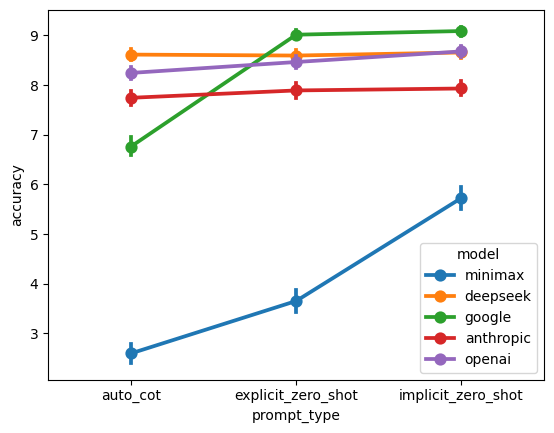

In [18]:
import seaborn as sns
sns.pointplot(data=anova_df, x="prompt_type", y="accuracy", hue="model")


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=anova_df["accuracy"],
    groups=anova_df["prompt_type"],
    alpha=0.05
)

print(tukey)


           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1             group2       meandiff p-adj lower  upper  reject
-------------------------------------------------------------------------
          auto_cot explicit_zero_shot   0.7316   0.0 0.6016 0.8616   True
          auto_cot implicit_zero_shot    1.224   0.0 1.0941  1.354   True
explicit_zero_shot implicit_zero_shot   0.4924   0.0 0.3625 0.6224   True
-------------------------------------------------------------------------


Auto-CoT (best)
Explicit zero-shot
Implicit zero-shot (worst)

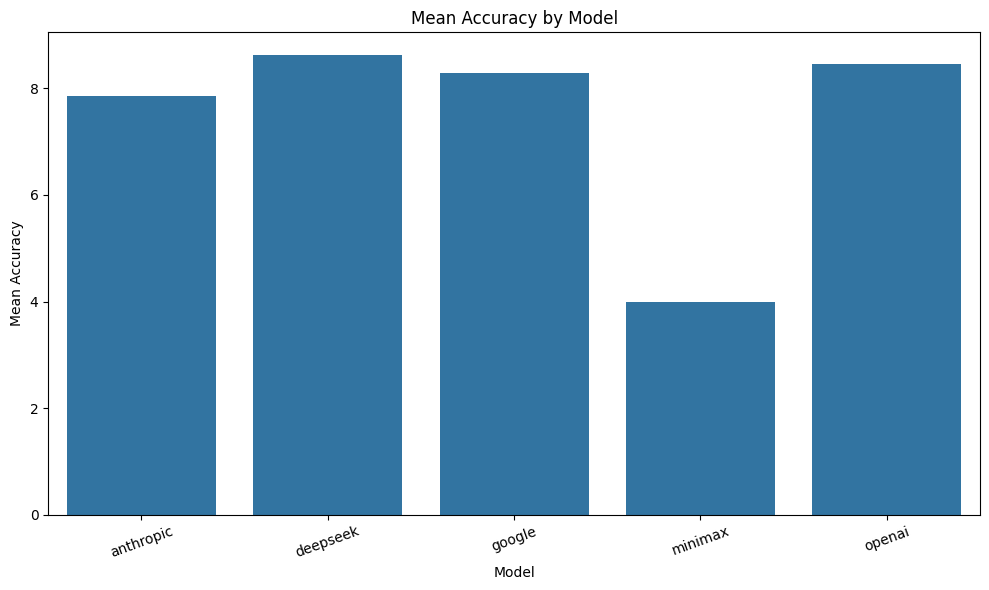

In [19]:
model_means = anova_df.groupby("model")["accuracy"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=model_means,
    x="model",
    y="accuracy"
)
plt.title("Mean Accuracy by Model")
plt.ylabel("Mean Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


deepseek shows overall better accuracy.

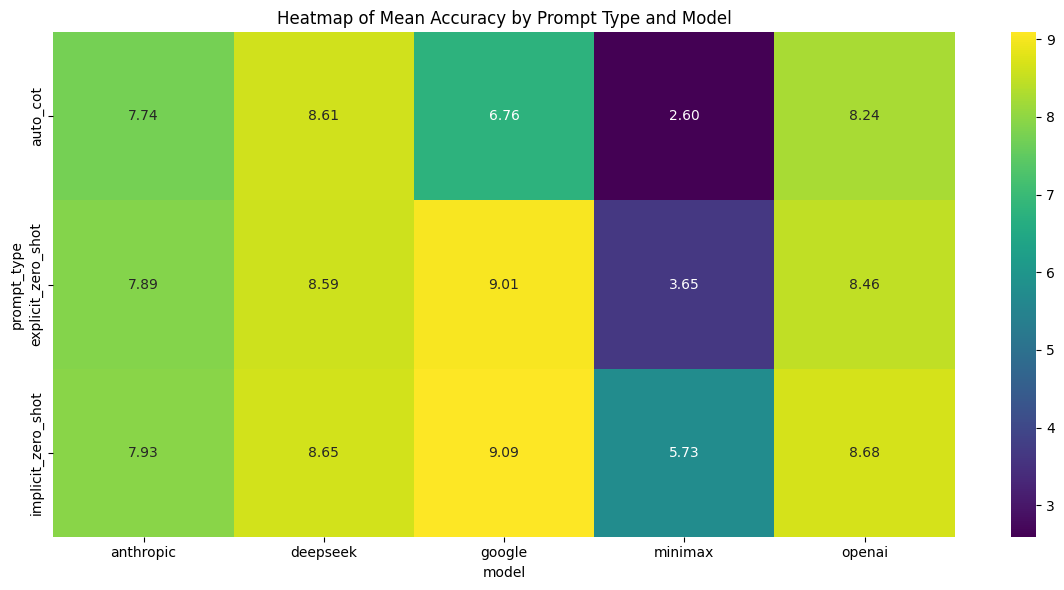

In [20]:
pivot = anova_df.pivot_table(
    values="accuracy",
    index="prompt_type",
    columns="model",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Heatmap of Mean Accuracy by Prompt Type and Model")
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv")

# Keep only useful columns
metric_cols = [c for c in df.columns if "__accuracy" in c or "__completeness" in c or "__relevance" in c or "__coherence" in c]

df_ml = df[metric_cols].copy()

# Create overall score per response
df_ml["overall_score"] = df_ml.mean(axis=1)

print(df_ml.head())
#overall score is average of all metrics


   auto_cot__minimax__minimax-m2__accuracy  \
0                                      0.0   
1                                     10.0   
2                                     10.0   
3                                      0.0   
4                                      0.0   

   auto_cot__minimax__minimax-m2__completeness  \
0                                          0.0   
1                                         10.0   
2                                         10.0   
3                                          0.0   
4                                          0.0   

   auto_cot__minimax__minimax-m2__relevance  \
0                                       0.0   
1                                      10.0   
2                                      10.0   
3                                       0.0   
4                                       0.0   

   auto_cot__minimax__minimax-m2__coherence  \
0                                       0.0   
1                                      10.0  

In [23]:
from sklearn.preprocessing import StandardScaler

X = df_ml.drop("overall_score", axis=1)
y = df_ml["overall_score"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% information
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("Reduced features after PCA:", X_pca.shape[1])


Original features: 60
Reduced features after PCA: 19


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)


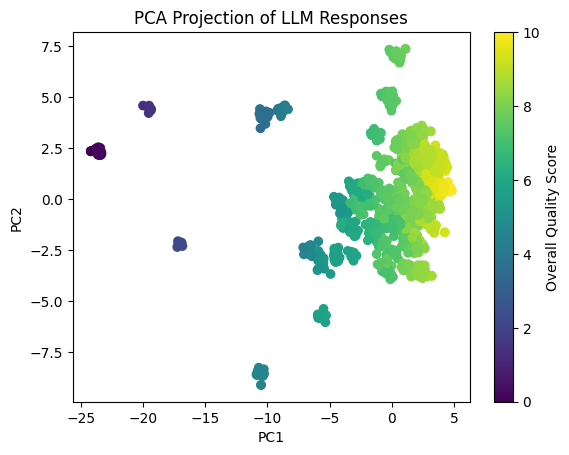

In [26]:
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap="viridis")
plt.colorbar(label="Overall Quality Score")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of LLM Responses")
plt.show()


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("Best RF Params:", rf_search.best_params_)


Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}


In [28]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_rf = best_rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


RF R2: 0.9991089362908461
RF RMSE: 0.056609966474967126


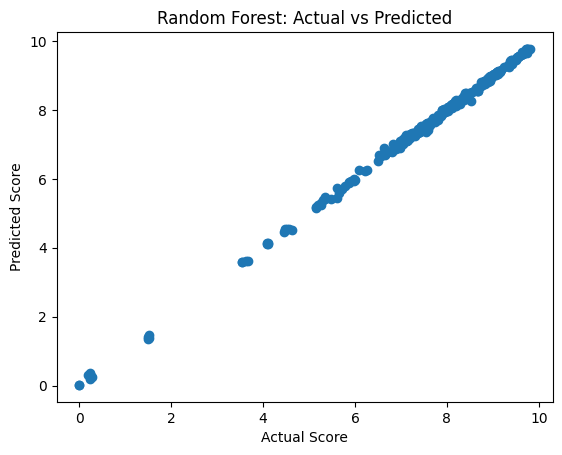

In [29]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Model behaves very similar to actual scores

In [30]:
!pip install xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    tree_method="gpu_hist",   # ✅ USE GPU
    predictor="gpu_predictor",
    random_state=42
)

xgb_params = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=8,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGB Params:", xgb_search.best_params_)


KeyboardInterrupt: 

In [39]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/JUDGED_RESULTS_FINAL_augmented.csv")
accuracy_cols     = [c for c in df.columns if c.endswith("__accuracy")]
completeness_cols = [c for c in df.columns if c.endswith("__completeness")]
relevance_cols    = [c for c in df.columns if c.endswith("__relevance")]
coherence_cols    = [c for c in df.columns if c.endswith("__coherence")]

print("Accuracy cols:", len(accuracy_cols))
print("Completeness cols:", len(completeness_cols))
print("Relevance cols:", len(relevance_cols))
print("Coherence cols:", len(coherence_cols))
df["accuracy"]     = df[accuracy_cols].mean(axis=1)
df["completeness"] = df[completeness_cols].mean(axis=1)
df["relevance"]    = df[relevance_cols].mean(axis=1)
df["coherence"]    = df[coherence_cols].mean(axis=1)

# Keep only the final ML-ready columns
df_final = df[["Question", "accuracy", "completeness", "relevance", "coherence"]].copy()

df_final.to_csv("/content/drive/MyDrive/FINAL_ML_READY.csv", index=False)

print("✅ FINAL ML READY FILE SAVED")
print(df_final.head())
# Create overall score per response
df = df[["accuracy", "completeness", "relevance", "coherence"]]
df["overall_score"] = df.mean(axis=1)
def label_quality(score):
    if score < 4:
        return "Poor"
    elif score < 7:
        return "Average"
    else:
        return "Good"

print(df.head())
#overall score is average of all metrics

df["quality_label"] = df["overall_score"].apply(label_quality)

print(df[["overall_score", "quality_label"]].head())

Accuracy cols: 15
Completeness cols: 15
Relevance cols: 15
Coherence cols: 15
✅ FINAL ML READY FILE SAVED
                                            Question  accuracy  completeness  \
0  Was Abraham Lincoln the sixteenth President of...  9.333333      9.333333   
1  Did Lincoln sign the National Banking Act of 1...  9.333333      9.333333   
2                   Did his mother die of pneumonia?  4.133333      4.133333   
3      How many long was Lincoln's formal education?  6.933333      5.666667   
4       When did Lincoln begin his political career?  7.333333      6.666667   

   relevance  coherence  
0   9.333333   9.333333  
1   9.333333   9.333333  
2   4.533333   5.266667  
3   7.333333   7.000000  
4   7.866667   7.733333  
   accuracy  completeness  relevance  coherence  overall_score
0  9.333333      9.333333   9.333333   9.333333       9.333333
1  9.333333      9.333333   9.333333   9.333333       9.333333
2  4.133333      4.133333   4.533333   5.266667       4.516667
3  6.

In [41]:
X = df[["accuracy", "completeness", "relevance", "coherence"]]
y = df["quality_label"]


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("LOGISTIC REGRESSION ACCURACY:", accuracy_score(y_test, y_pred_log))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred_log))


LOGISTIC REGRESSION ACCURACY: 0.9819819819819819

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Average       0.98      0.91      0.94        56
        Good       0.98      1.00      0.99       262
        Poor       1.00      0.93      0.97        15

    accuracy                           0.98       333
   macro avg       0.99      0.95      0.97       333
weighted avg       0.98      0.98      0.98       333



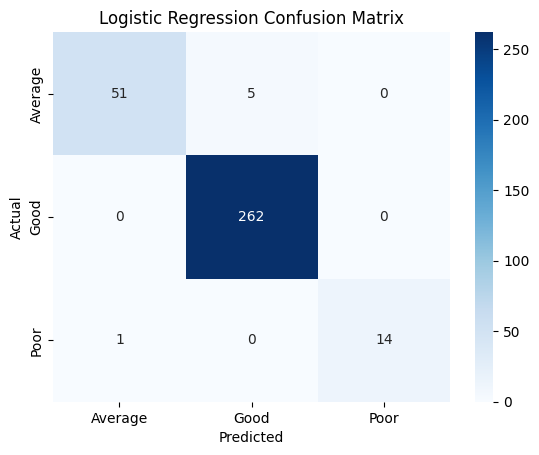

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Average", "Good", "Poor"],
            yticklabels=["Average", "Good", "Poor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST ACCURACY:", accuracy_score(y_test, y_pred_rf))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred_rf))


RANDOM FOREST ACCURACY: 0.984984984984985

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Average       1.00      0.91      0.95        56
        Good       0.98      1.00      0.99       262
        Poor       1.00      1.00      1.00        15

    accuracy                           0.98       333
   macro avg       0.99      0.97      0.98       333
weighted avg       0.99      0.98      0.98       333



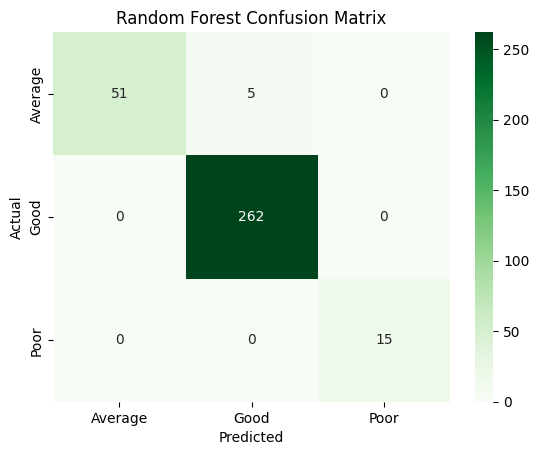

In [47]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Average", "Good", "Poor"],
            yticklabels=["Average", "Good", "Poor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [48]:
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)


        Feature  Importance
3     coherence    0.399971
1  completeness    0.279807
2     relevance    0.166689
0      accuracy    0.153533


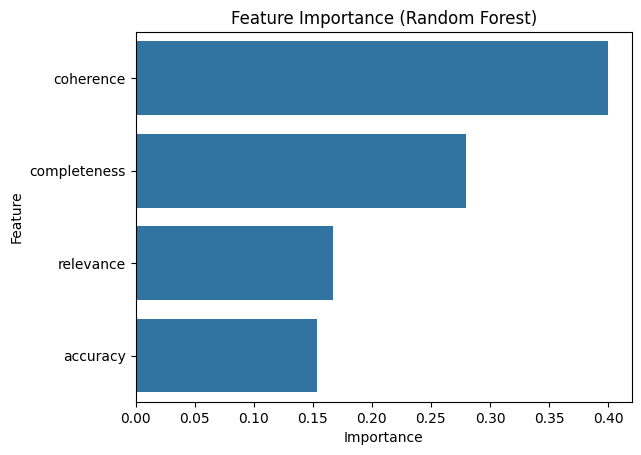

In [49]:
plt.figure()
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance (Random Forest)")
plt.show()


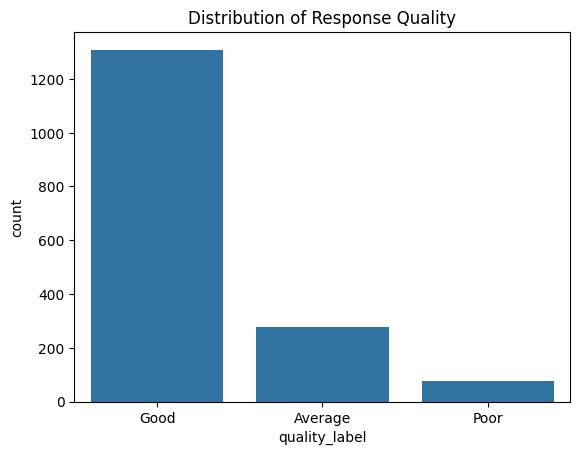

In [50]:
plt.figure()
sns.countplot(x=df["quality_label"])
plt.title("Distribution of Response Quality")
plt.show()
